# CineMA + 3D UNetR Decoder — ACDC Dense Segmentation

Evaluates a frozen CineMA backbone by attaching its own 3D `UpsampleDecoder`.
CineMA's conv encoder provides natural multi-scale skip connections at 96², 48²,
and 24² spatial resolutions, which are combined with ViT features and decoded
with the same 3D UNetR architecture used inside `ConvUNetR`.

This enables a fair comparison: **CineMA encoder vs DINOv3 encoder**, with an
identical 3D decoder.

In [1]:
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from cinema import CineMA
from cinema.segmentation.dataset import EndDiastoleEndSystoleDataset
from monai.transforms import ScaleIntensityd
from torch.utils.data import DataLoader

from heartfm_evals.dense_linear_probe import (
    CLASS_COLORS,
    CLASS_NAMES,
    IMAGE_SIZE,
    NUM_CLASSES,
    macro_dice,
    overlay_labels,
)
from heartfm_evals.dense_unetr_probe import (
    SAX_TARGET_DEPTH,
    CachedCinemaVolumeDataset,
    CineMAUNetRDecoder,
    MaskedVolumeLoss,
    cache_cinema_volume_features,
    evaluate_vol,
    train_one_epoch_vol,
)

## Configuration

In [2]:
# -- Paths --
ACDC_DATA_DIR = Path("/Users/lbokeria/projects/health_gc/data/heartfm/processed/acdc/")

# -- CineMA loading --
HF_CACHE_DIR = Path("../model_weights/hf")
AUTO_DOWNLOAD = True

# -- CineMA encoder config (from pretrained model) --
# DownsampleEncoder produces len(enc_conv_chans) conv skips; for the default
# SAX config that is 2 skips at 48² and 24², NOT 3.
ENC_EMBED_DIM = 768
ENC_CONV_CHANS = (64, 128)

# -- 3D UNetR decoder config (matches CineMA segmentation.yaml) --
DEC_CHANS = (32, 64, 128, 256, 512)
DEC_PATCH_SIZE = (2, 2, 1)
DEC_SCALE_FACTOR = (2, 2, 1)
N_LAYERS_WO_SKIP = 1  # decoder levels with no encoder skip
Z_PAD = SAX_TARGET_DEPTH  # 16

# -- Cache --
CACHE_DIR = Path("../feature_cache/cinema_pretrained_unetr3d")

# -- Training --
BATCH_SIZE = 4  # volumes use ~16x more memory than 2D slices
LR = 1e-3
WEIGHT_DECAY = 1e-4
N_EPOCHS = 2
PATIENCE = 10

# -- Device --
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Using device: {DEVICE}")
print(f"Backbone: CineMA pretrained (embed_dim={ENC_EMBED_DIM}, conv_chans={ENC_CONV_CHANS})")
print(f"Decoder: UpsampleDecoder(3D) chans={DEC_CHANS}, Z-pad={Z_PAD}")

Using device: mps
Backbone: CineMA pretrained (embed_dim=768, conv_chans=(64, 128))
Decoder: UpsampleDecoder(3D) chans=(32, 64, 128, 256, 512), Z-pad=16


## Data Loading

In [3]:
train_meta_df = pd.read_csv(ACDC_DATA_DIR / "train_metadata.csv")
test_meta_df = pd.read_csv(ACDC_DATA_DIR / "test_metadata.csv")

if "pathology" in train_meta_df.columns:
    val_pids = (
        train_meta_df.groupby("pathology")
        .sample(n=2, random_state=0)["pid"]
        .tolist()
    )
else:
    val_pids = train_meta_df.sample(frac=0.1, random_state=0)["pid"].tolist()

train_split_df = train_meta_df[~train_meta_df["pid"].isin(val_pids)].reset_index(drop=True)
val_split_df = train_meta_df[train_meta_df["pid"].isin(val_pids)].reset_index(drop=True)

print(f"Train split: {len(train_split_df)} patients")
print(f"Val split:   {len(val_split_df)} patients")
print(f"Test set:    {len(test_meta_df)} patients")

Train split: 90 patients
Val split:   10 patients
Test set:    50 patients


In [4]:
transform = ScaleIntensityd(keys="sax_image", factor=1 / 255, channel_wise=False)

train_cinema = EndDiastoleEndSystoleDataset(
    data_dir=ACDC_DATA_DIR / "train",
    meta_df=train_split_df,
    views="sax",
    transform=transform,
)

val_cinema = EndDiastoleEndSystoleDataset(
    data_dir=ACDC_DATA_DIR / "train",
    meta_df=val_split_df,
    views="sax",
    transform=transform,
)

test_cinema = EndDiastoleEndSystoleDataset(
    data_dir=ACDC_DATA_DIR / "test",
    meta_df=test_meta_df,
    views="sax",
    transform=transform,
)

print(f"Train CineMA dataset: {len(train_cinema)} samples")
print(f"Val CineMA dataset:   {len(val_cinema)} samples")
print(f"Test CineMA dataset:  {len(test_cinema)} samples")

Train CineMA dataset: 180 samples
Val CineMA dataset:   20 samples
Test CineMA dataset:  100 samples


## Backbone Loading & Volume Feature Caching

In [5]:
backbone = CineMA.from_pretrained(
    cache_dir=str(HF_CACHE_DIR),
    local_files_only=not AUTO_DOWNLOAD,
)
backbone.eval().to(DEVICE)
for p in backbone.parameters():
    p.requires_grad = False

print(f"Loaded CineMA pretrained backbone ({sum(p.numel() for p in backbone.parameters()):,} params, frozen)")
print(f"SAX grid: {backbone.enc_down_dict['sax'].patch_embed.grid_size}, embed_dim: {ENC_EMBED_DIM}")

MainThread-22901 | 2026-03-26 11:55:37-cinema.mae.mae-from_pretrained:623 | [INFO] Cached model weights to ../model_weights/hf/models--mathpluscode--CineMA/snapshots/b1251ee50423bceeca84c080782fc3bc7756dea6/pretrained/cinema.safetensors.
MainThread-22901 | 2026-03-26 11:55:37-cinema.mae.mae-from_pretrained:635 | [INFO] Cached model config to ../model_weights/hf/models--mathpluscode--CineMA/snapshots/b1251ee50423bceeca84c080782fc3bc7756dea6/pretrained/config.yaml.
MainThread-22901 | 2026-03-26 11:55:39-cinema.mae.mae-from_pretrained:641 | [INFO] Loaded pretrained weights.
Loaded CineMA pretrained backbone (125,670,400 params, frozen)
SAX grid: (12, 12, 16), embed_dim: 768


In [6]:
print("Caching training volume features...")
train_manifest = cache_cinema_volume_features(
    backbone, train_cinema, CACHE_DIR / "train",
    device=DEVICE, target_depth=Z_PAD,
)

print("\nCaching validation volume features...")
val_manifest = cache_cinema_volume_features(
    backbone, val_cinema, CACHE_DIR / "val",
    device=DEVICE, target_depth=Z_PAD,
)

print("\nCaching test volume features...")
test_manifest = cache_cinema_volume_features(
    backbone, test_cinema, CACHE_DIR / "test",
    device=DEVICE, target_depth=Z_PAD,
)

sample = torch.load(train_manifest[0]["path"], weights_only=True)
print(f"\nCached train volumes: {len(train_manifest)}")
print(f"Cached val volumes:   {len(val_manifest)}")
print(f"Cached test volumes:  {len(test_manifest)}")
print(f"Image shape:        {sample['image'].shape}")
print(f"Label shape:        {sample['label'].shape}")
for i in range(len(ENC_CONV_CHANS)):
    print(f"conv_skip_{i} shape: {sample[f'conv_skip_{i}'].shape}")
print(f"vit_features shape: {sample['vit_features'].shape}")
print(f"n_slices:           {sample['n_slices']}")

Caching training volume features...


Caching CineMA volume features: 100%|██████████| 180/180 [02:34<00:00,  1.17it/s]



Caching validation volume features...


Caching CineMA volume features: 100%|██████████| 20/20 [00:17<00:00,  1.16it/s]



Caching test volume features...


Caching CineMA volume features: 100%|██████████| 100/100 [01:25<00:00,  1.17it/s]


Cached train volumes: 180
Cached val volumes:   20
Cached test volumes:  100
Image shape:        torch.Size([1, 192, 192, 16])
Label shape:        torch.Size([1, 192, 192, 16])
conv_skip_0 shape: torch.Size([64, 48, 48, 16])
conv_skip_1 shape: torch.Size([128, 24, 24, 16])
vit_features shape: torch.Size([768, 12, 12, 16])
n_slices:           10


## Model, Loss & Training Setup

In [7]:
train_ds = CachedCinemaVolumeDataset(train_manifest, n_conv_skips=len(ENC_CONV_CHANS))
val_ds = CachedCinemaVolumeDataset(val_manifest, n_conv_skips=len(ENC_CONV_CHANS))
test_ds = CachedCinemaVolumeDataset(test_manifest, n_conv_skips=len(ENC_CONV_CHANS))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Model
probe = CineMAUNetRDecoder(
    enc_embed_dim=ENC_EMBED_DIM,
    enc_conv_chans=ENC_CONV_CHANS,
    dec_chans=DEC_CHANS,
    dec_patch_size=DEC_PATCH_SIZE,
    dec_scale_factor=DEC_SCALE_FACTOR,
    num_classes=NUM_CLASSES,
    n_layers_wo_skip=N_LAYERS_WO_SKIP,
).to(DEVICE)

# Class weights from training set
class_counts = torch.zeros(NUM_CLASSES, dtype=torch.long)
for entry in train_manifest:
    data = torch.load(entry["path"], weights_only=True)
    ns = data["n_slices"]
    label_valid = data["label"][0, :, :, :ns]  # only valid slices
    class_counts += torch.bincount(label_valid.reshape(-1), minlength=NUM_CLASSES)

class_weights = class_counts.sum().float() / (NUM_CLASSES * class_counts.clamp_min(1).float())
class_weights[0] = class_weights[0] * 0.5  # reduce BG weight
class_weights = class_weights / class_weights.mean()

criterion = MaskedVolumeLoss(class_weights.to(DEVICE), ce_weight=1.0, dice_weight=1.0)
optimizer = torch.optim.AdamW(probe.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

print(f"Decoder config: chans={DEC_CHANS}, patch_size={DEC_PATCH_SIZE}, scale_factor={DEC_SCALE_FACTOR}")
print(f"Class weights (BG/RV/MYO/LV): {class_weights.tolist()}")
print(f"Trainable params: {sum(p.numel() for p in probe.parameters() if p.requires_grad):,}")

Decoder config: chans=(32, 64, 128, 256, 512), patch_size=(2, 2, 1), scale_factor=(2, 2, 1)
Class weights (BG/RV/MYO/LV): [0.03057108074426651, 1.3994539976119995, 1.2823073863983154, 1.2876677513122559]
Trainable params: 39,083,302


## Training

In [8]:
best_val_dice = 0.0
best_epoch = 0
epochs_no_improve = 0
history = {"train_loss": [], "val_macro_dice": [], "lr": []}

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_one_epoch_vol(
        probe, train_loader, criterion, optimizer, DEVICE,
    )
    scheduler.step()

    val_metrics = evaluate_vol(probe, val_loader, DEVICE)
    val_dice = val_metrics["macro_dice"]

    history["train_loss"].append(train_loss)
    history["val_macro_dice"].append(val_dice)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    improved = val_dice > best_val_dice
    if epoch == 1 or epoch % 5 == 0 or improved:
        tag = " *" if improved else ""
        print(
            f"Epoch {epoch:3d}/{N_EPOCHS} | loss={train_loss:.4f} | val Dice={val_dice:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e}{tag}"
        )

    if improved:
        best_val_dice = val_dice
        best_epoch = epoch
        epochs_no_improve = 0
        best_state = {k: v.detach().cpu().clone() for k, v in probe.state_dict().items()}
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch}. Best val Dice={best_val_dice:.4f} at epoch {best_epoch}.")
            break

probe.load_state_dict(best_state)
print(f"Restored best checkpoint from epoch {best_epoch} (val Dice={best_val_dice:.4f})")

Epoch   1/2 | loss=1.4233 | val Dice=0.7157 | lr=5.00e-04 *
Epoch   2/2 | loss=0.4937 | val Dice=0.8176 | lr=0.00e+00 *
Restored best checkpoint from epoch 2 (val Dice=0.8176)


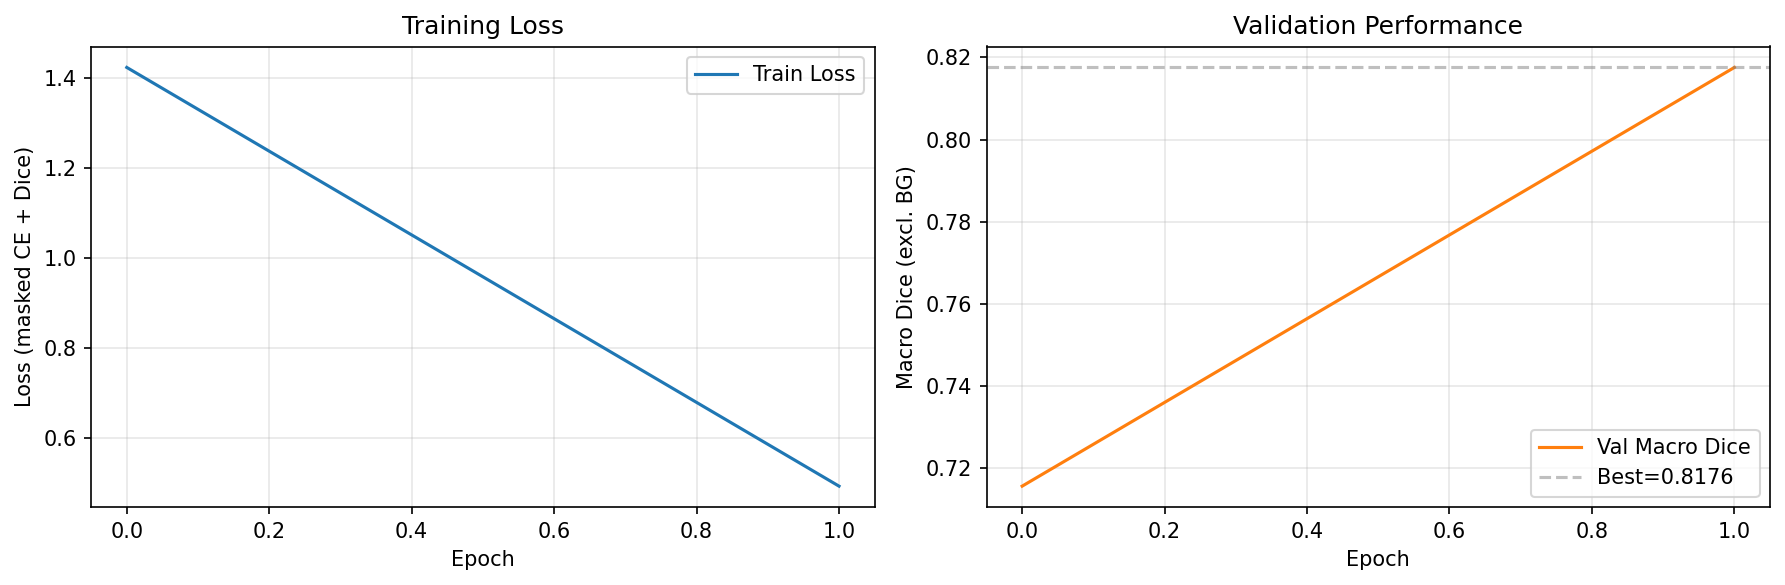

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=150)
ax1.plot(history["train_loss"], label="Train Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss (masked CE + Dice)")
ax1.set_title("Training Loss")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(history["val_macro_dice"], label="Val Macro Dice", color="tab:orange")
ax2.axhline(best_val_dice, ls="--", color="gray", alpha=0.5, label=f"Best={best_val_dice:.4f}")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Macro Dice (excl. BG)")
ax2.set_title("Validation Performance")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

## Test Evaluation

In [10]:
test_metrics = evaluate_vol(probe, test_loader, DEVICE)

print("Per-class Dice scores (test set):")
for name, d in test_metrics["per_class_dice"].items():
    print(f"  {name:>3s}: {d:.4f}")
print(f"\nMacro Dice (excl. BG): {test_metrics['macro_dice']:.4f}")

Per-class Dice scores (test set):
   BG: 0.9823
   RV: 0.8069
  MYO: 0.6916
   LV: 0.8930

Macro Dice (excl. BG): 0.7972


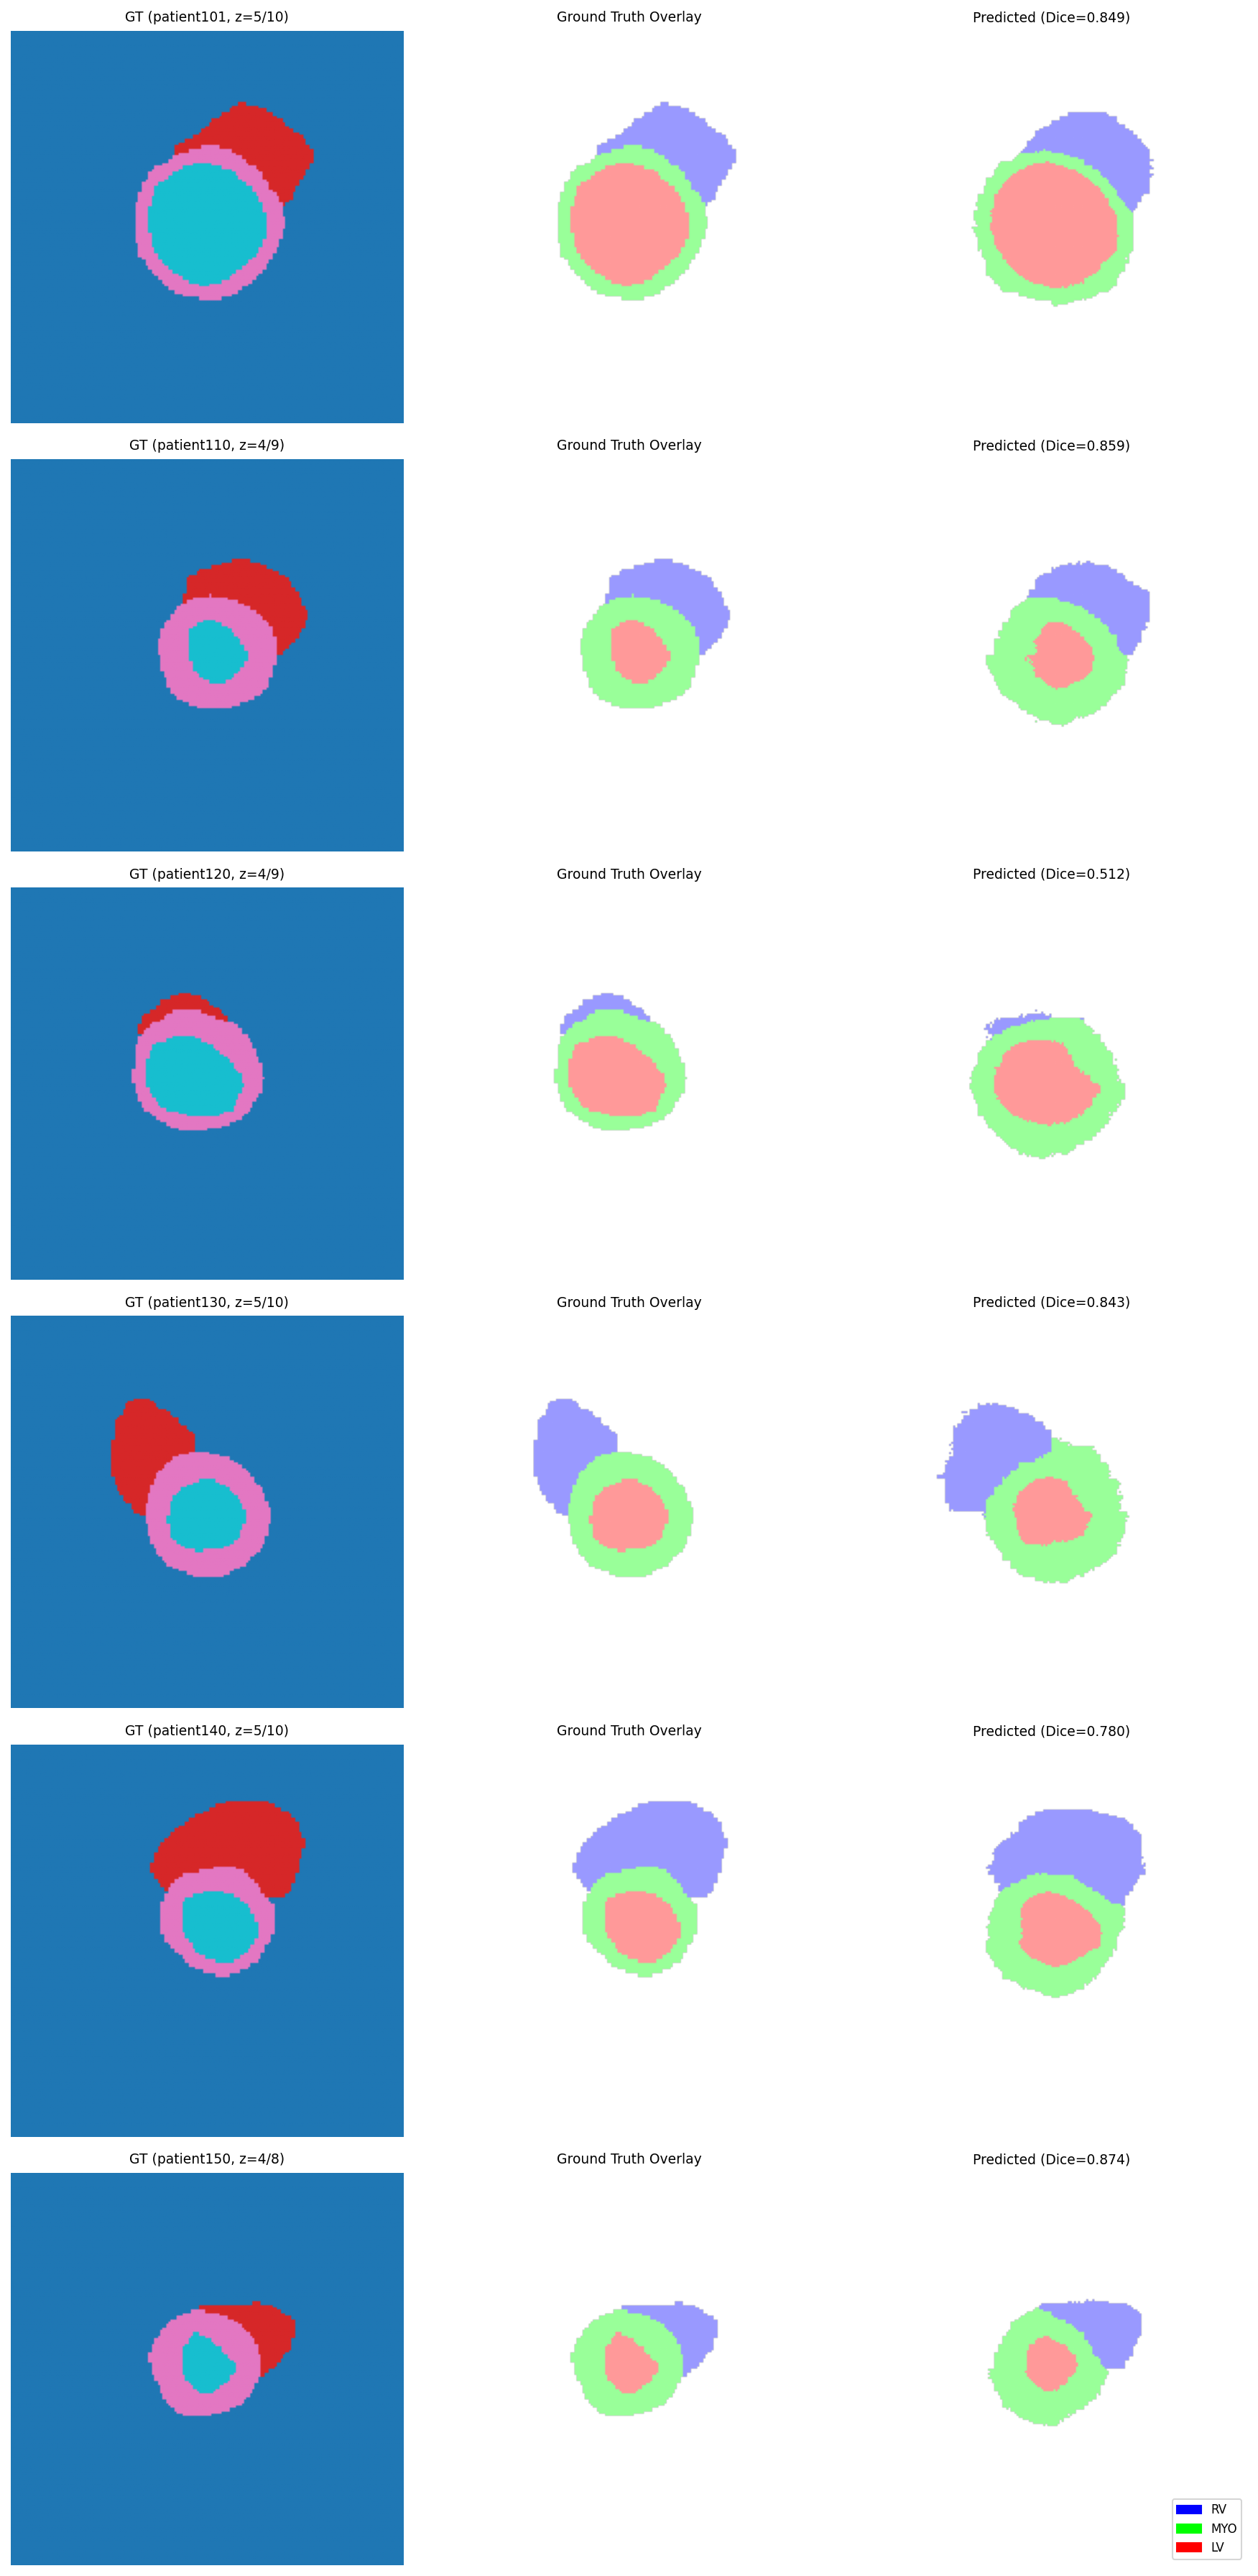

In [11]:
# Show predictions for a few test volumes (middle z-slice of each)
n_show = min(6, len(test_manifest))
show_indices = np.linspace(0, len(test_manifest) - 1, n_show, dtype=int)

fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show), dpi=150)
if n_show == 1:
    axes = axes[np.newaxis, :]

probe.eval()
with torch.inference_mode():
    for row, vol_idx in enumerate(show_indices):
        entry = test_manifest[vol_idx]
        data = torch.load(entry["path"], weights_only=True)
        ns = data["n_slices"]
        mid_z = ns // 2  # pick middle slice

        # Build single-volume batch
        batch_gpu = {"image": data["image"].unsqueeze(0).to(DEVICE)}
        batch_gpu["vit_features"] = data["vit_features"].unsqueeze(0).to(DEVICE)
        for i in range(len(ENC_CONV_CHANS)):
            batch_gpu[f"conv_skip_{i}"] = data[f"conv_skip_{i}"].unsqueeze(0).to(DEVICE)

        logits = probe(batch_gpu)
        pred_vol = logits.argmax(dim=1).squeeze(0).cpu().numpy()  # (H, W, Z)
        pred = pred_vol[:, :, mid_z]
        label = data["label"][0, :, :, mid_z].numpy()

        gt_overlay = overlay_labels(label, IMAGE_SIZE, IMAGE_SIZE)
        pred_overlay = overlay_labels(pred, IMAGE_SIZE, IMAGE_SIZE)

        axes[row, 0].imshow(label, cmap="tab10", vmin=0, vmax=3)
        axes[row, 0].set_title(f"GT ({entry['pid']}, z={mid_z}/{ns})", fontsize=9)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(gt_overlay)
        axes[row, 1].set_title("Ground Truth Overlay", fontsize=9)
        axes[row, 1].axis("off")

        axes[row, 2].imshow(pred_overlay)
        axes[row, 2].set_title(f"Predicted (Dice={macro_dice(pred, label):.3f})", fontsize=9)
        axes[row, 2].axis("off")

legend_patches = [
    mpatches.Patch(color=CLASS_COLORS[c][:3] + (1.0,), label=CLASS_NAMES[c])
    for c in range(1, NUM_CLASSES)
]
axes[-1, 2].legend(handles=legend_patches, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## Save Model

In [12]:
save_path = Path("dense_unetr3d_probe_cinema.pt")
torch.save(
    {
        "model_state_dict": probe.state_dict(),
        "backbone": "mathpluscode/CineMA",
        "enc_embed_dim": ENC_EMBED_DIM,
        "enc_conv_chans": ENC_CONV_CHANS,
        "dec_chans": DEC_CHANS,
        "dec_patch_size": DEC_PATCH_SIZE,
        "dec_scale_factor": DEC_SCALE_FACTOR,
        "n_layers_wo_skip": N_LAYERS_WO_SKIP,
        "num_classes": NUM_CLASSES,
        "z_pad": Z_PAD,
        "best_epoch": best_epoch,
        "best_val_dice": best_val_dice,
        "test_metrics": test_metrics,
        "val_pids": val_pids,
    },
    save_path,
)
print(f"Model saved to {save_path}")

Model saved to dense_unetr3d_probe_cinema.pt
